In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
df = pd.read_csv('18.01.11_US_videos.csv')

In [60]:
df.head()

,video_id,title,publishedAt,channelId,channelTitle,categoryId,trending_date,tags,view_count,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,description
0,U68MJz9DrI4,"Gucci Mane, Bruno Mars, Kodak Black - Wake Up ...",2018-10-31T14:17:10.000Z,UCSugZEYrWbzqIWGD195V-YA,OfficialGucciMane,10,18.01.11,officialguccimane|gucci mane|gucci|mane|atlant...,673533,91342,1480,8204,https://i.ytimg.com/vi/U68MJz9DrI4/default.jpg,False,False,"The official music video for Gucci Mane, Bruno..."
1,shWNgr0ifrs,Kevin Gates - Great Man [Official Music Video],2018-10-31T14:00:08.000Z,UCj2GTFekdV3EUsTVN8oaEqA,kevingatesTV,10,18.01.11,kevin gates|kevin|gates|atlantic|atlantic reco...,207289,18647,256,1707,https://i.ytimg.com/vi/shWNgr0ifrs/default.jpg,False,False,Kevin Gates - Great ManStream/Download - https...
2,JIFMN986m8s,Worst Halloween Candy Taste Test (Day 3),2018-10-31T10:00:03.000Z,UC4PooiX37Pld1T8J5SYT-SQ,Good Mythical Morning,24,18.01.11,gmm|good mythical morning|rhettandlink|rhett a...,1054156,39129,1236,10153,https://i.ytimg.com/vi/JIFMN986m8s/default.jpg,False,False,We've arrived at the finals! Which of our Ehh ...
3,0iy3HPxBFQY,James Corden & Ariana Grande Visit an Escape Room,2018-10-31T05:01:11.000Z,UCJ0uqCI0Vqr2Rrt1HseGirg,The Late Late Show with James Corden,24,18.01.11,The Late Late Show|Late Late Show|James Corden...,896693,49252,289,2247,https://i.ytimg.com/vi/0iy3HPxBFQY/default.jpg,False,False,Since Ariana Grande loves Halloween and being ...
4,XeAClxSYQc8,Ellen's Backstage Scares Featuring Kris Jenner...,2018-10-31T13:00:04.000Z,UCp0hYYBW6IMayGgR-WeoCvQ,TheEllenShow,24,18.01.11,scare|montage|ellen staff|tv|kris jenner|ciara...,408612,18862,207,0,https://i.ytimg.com/vi/XeAClxSYQc8/default.jpg,True,False,One of Ellen's favorite parts of Halloween is ...


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   video_id           200 non-null    object
 1   title              200 non-null    object
 2   publishedAt        200 non-null    object
 3   channelId          200 non-null    object
 4   channelTitle       200 non-null    object
 5   categoryId         200 non-null    int64 
 6   trending_date      200 non-null    object
 7   tags               200 non-null    object
 8   view_count         200 non-null    int64 
 9   likes              200 non-null    int64 
 10  dislikes           200 non-null    int64 
 11  comment_count      200 non-null    int64 
 12  thumbnail_link     200 non-null    object
 13  comments_disabled  200 non-null    bool  
 14  ratings_disabled   200 non-null    bool  
 15  description        198 non-null    object
dtypes: bool(2), int64(5), object(9)
memory usage

In [62]:
df.isna().sum()

video_id             0
title                0
publishedAt          0
channelId            0
channelTitle         0
categoryId           0
trending_date        0
tags                 0
view_count           0
likes                0
dislikes             0
comment_count        0
thumbnail_link       0
comments_disabled    0
ratings_disabled     0
description          2
dtype: int64

In [63]:
df['description'] = df['description'].fillna("No Description")


In [64]:
df.shape[0]

200

In [65]:
df = df.drop_duplicates(subset='video_id')

In [66]:
df.shape[0]

200

In [67]:
df['publishedAt'] = pd.to_datetime(df['publishedAt'], errors='coerce')
df['trending_date'] = pd.to_datetime(df['trending_date'], errors='coerce')

In [68]:
numeric_cols = ['view_count', 'likes', 'dislikes', 'comment_count']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [69]:
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

In [70]:
df_clean = df[~((df[numeric_cols] < (Q1 - 1.5 * IQR)) |
                (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

In [71]:
df_clean.shape[0]

162

In [72]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 162 entries, 0 to 199
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   video_id           162 non-null    object             
 1   title              162 non-null    object             
 2   publishedAt        162 non-null    datetime64[ns, UTC]
 3   channelId          162 non-null    object             
 4   channelTitle       162 non-null    object             
 5   categoryId         162 non-null    int64              
 6   trending_date      162 non-null    datetime64[ns]     
 7   tags               162 non-null    object             
 8   view_count         162 non-null    int64              
 9   likes              162 non-null    int64              
 10  dislikes           162 non-null    int64              
 11  comment_count      162 non-null    int64              
 12  thumbnail_link     162 non-null    object             


In [73]:
df_clean.isna().sum()

video_id             0
title                0
publishedAt          0
channelId            0
channelTitle         0
categoryId           0
trending_date        0
tags                 0
view_count           0
likes                0
dislikes             0
comment_count        0
thumbnail_link       0
comments_disabled    0
ratings_disabled     0
description          0
dtype: int64

In [74]:
top_views = df.sort_values(by='view_count', ascending=False).head(10)

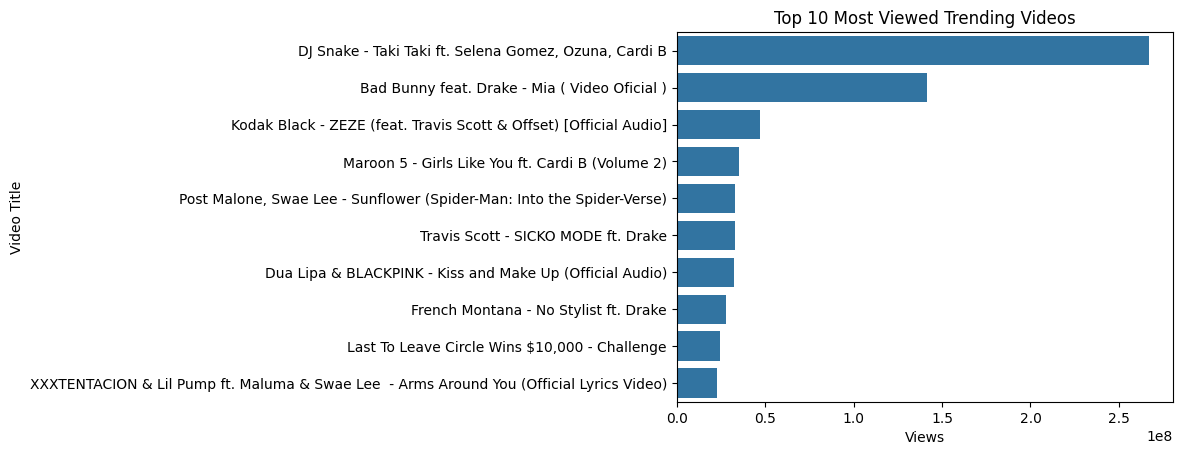

In [75]:
plt.figure()
sns.barplot(x='view_count', y='title', data=top_views)
plt.title("Top 10 Most Viewed Trending Videos")
plt.xlabel("Views")
plt.ylabel("Video Title")
plt.show()

In [76]:
top_channels = df['channelTitle'].value_counts().head(10)

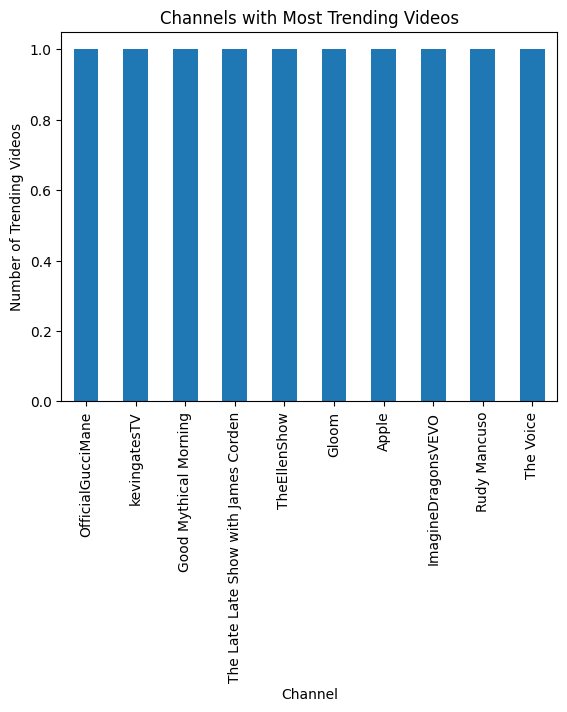

In [77]:
plt.figure()
top_channels.plot(kind = 'bar')
plt.title("Channels with Most Trending Videos")
plt.xlabel("Channel")
plt.ylabel("Number of Trending Videos")
plt.show()

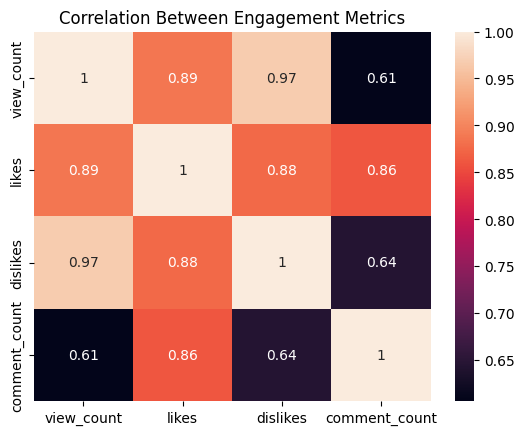

In [78]:
engagement_cols = ['view_count','likes','dislikes','comment_count']

plt.figure()
sns.heatmap(df[engagement_cols].corr(), annot=True)
plt.title("Correlation Between Engagement Metrics")
plt.show()


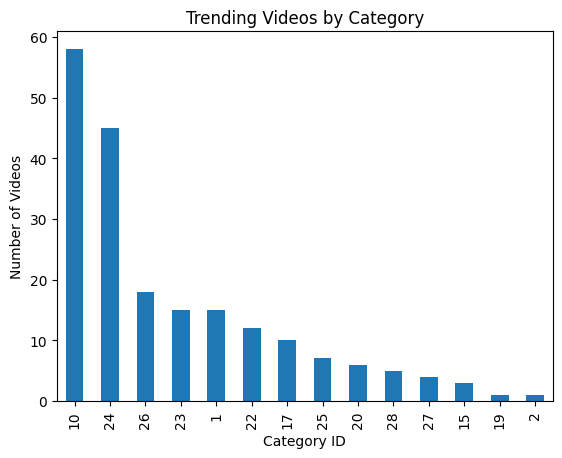

In [79]:
plt.figure()
df['categoryId'].value_counts().plot(kind='bar')
plt.title("Trending Videos by Category")
plt.xlabel("Category ID")
plt.ylabel("Number of Videos")
plt.show()

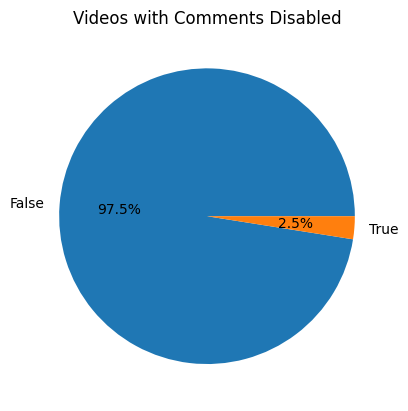

In [80]:
comments_disabled = df['comments_disabled'].value_counts()

plt.figure()
comments_disabled.plot(kind='pie', autopct='%1.1f%%')
plt.title("Videos with Comments Disabled")
plt.ylabel("")
plt.show()

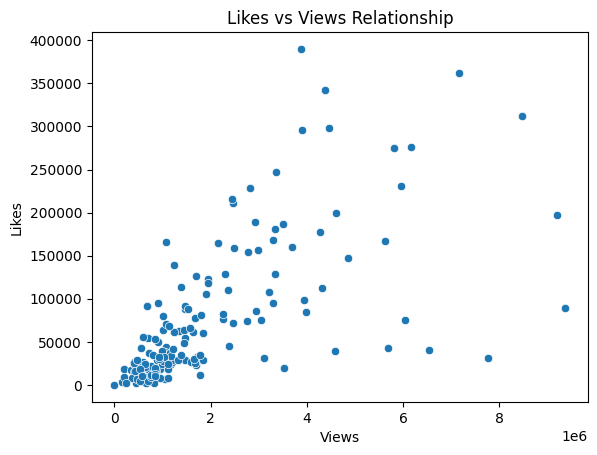

In [81]:
plt.figure()
sns.scatterplot(x='view_count', y='likes', data=df_clean)
plt.title("Likes vs Views Relationship")
plt.xlabel("Views")
plt.ylabel("Likes")
plt.show()